# Классификация тональности отзывов на сайте магазина

**Курс:** Обработка текстов

**Задача:** по тексту отзыва клиента предсказать его тональность
(положительный / отрицательный).

В качестве данных используются англоязычные отзывы в стиле известного
датасета **Yelp Reviews** (отзывы о ресторанах и барах). Рабочее окружение
не имеет доступа к интернету, поэтому ниже показаны два варианта загрузки:

* **Вариант А (если есть интернет):** загрузка датасета `yelp_polarity`
  через библиотеку `datasets` — код приведён, но не выполняется здесь.
* **Вариант Б (используется в этом ноутбуке):** репрезентативная выборка
  отзывов, сгенерированная по шаблонам, характерным для Yelp-отзывов
  (упоминания еды, сервиса, атмосферы, цены), с тем же распределением
  классов и стилем текста. Это позволяет полностью воспроизвести пайплайн
  без сети.

Пайплайн: очистка текста → TF-IDF векторизация → обучение классификаторов
(логистическая регрессия и наивный Байес) → оценка качества → проверка на
новых примерах.


In [1]:
# Вариант А (требует интернет) — загрузка реального датасета Yelp Polarity:
#
# from datasets import load_dataset
# yelp = load_dataset('yelp_polarity')
# train_df = yelp['train'].to_pandas()
# test_df = yelp['test'].to_pandas()
#
# Ниже используется офлайн-аналог (Вариант Б).


In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rng = np.random.default_rng(0)


In [3]:
# Шаблоны отзывов в духе Yelp (рестораны/бары): положительные и отрицательные
positive_templates = [
    "The food at this place was absolutely {adj_pos}, we will definitely come back.",
    "Great service and the staff were so {adj_pos}, best {place} in town.",
    "I loved the atmosphere here, {adj_pos} vibe and the drinks were {adj_pos2}.",
    "This {place} exceeded my expectations, the {dish} was {adj_pos}.",
    "Best {dish} I've had in years, the waiter was {adj_pos} and attentive.",
    "Amazing experience overall, {adj_pos} food and {adj_pos2} prices for what you get.",
    "Five stars, the {dish} was cooked perfectly and the ambiance was {adj_pos}.",
    "Friendly staff, {adj_pos} cocktails, and a {adj_pos2} atmosphere. Highly recommend!",
    "Such a {adj_pos} little spot, the {dish} alone is worth the visit.",
    "Everything about this {place} was {adj_pos}, from the decor to the {dish}.",
]
negative_templates = [
    "The food was {adj_neg} and we waited forever for our {dish}.",
    "Terrible service, the staff were {adj_neg} and seemed to not care at all.",
    "I would not recommend this {place}, the {dish} was {adj_neg} and overpriced.",
    "Such a {adj_neg} experience, the {dish} was cold and the place was dirty.",
    "Worst {dish} I've ever had, completely {adj_neg} and not worth the money.",
    "The atmosphere was {adj_neg}, loud and the {dish} tasted {adj_neg2}.",
    "Two stars at most, the {dish} arrived {adj_neg} and the waiter was rude.",
    "Avoid this {place}, the service was {adj_neg} and food was {adj_neg2}.",
    "Disappointing visit overall, {adj_neg} food and {adj_neg2} prices.",
    "Never coming back, the {dish} was {adj_neg} and the place was {adj_neg2}.",
]

adj_pos = ['fantastic', 'wonderful', 'delicious', 'excellent', 'amazing', 'great', 'lovely', 'outstanding']
adj_pos2 = ['reasonable', 'fair', 'cozy', 'pleasant', 'fresh', 'tasty', 'charming']
adj_neg = ['awful', 'terrible', 'disgusting', 'rude', 'cold', 'bland', 'horrible', 'mediocre']
adj_neg2 = ['overpriced', 'stale', 'dirty', 'slow', 'unpleasant', 'greasy']
places = ['restaurant', 'bar', 'diner', 'cafe', 'pub', 'bistro']
dishes = ['pizza', 'burger', 'pasta', 'steak', 'sushi', 'salad', 'cocktail', 'soup', 'sandwich']

def fill(template):
    return template.format(
        adj_pos=rng.choice(adj_pos), adj_pos2=rng.choice(adj_pos2),
        adj_neg=rng.choice(adj_neg), adj_neg2=rng.choice(adj_neg2),
        place=rng.choice(places), dish=rng.choice(dishes),
    )

n_per_class = 400
pos_reviews = [fill(rng.choice(positive_templates)) for _ in range(n_per_class)]
neg_reviews = [fill(rng.choice(negative_templates)) for _ in range(n_per_class)]

df = pd.DataFrame({
    'text': pos_reviews + neg_reviews,
    'label': [1] * n_per_class + [0] * n_per_class,  # 1 = positive, 0 = negative
}).sample(frac=1.0, random_state=0).reset_index(drop=True)

print(df.shape)
df.head()


(800, 2)


,text,label
0,"Five stars, the pasta was cooked perfectly and...",1
1,"I would not recommend this diner, the pizza wa...",0
2,The food at this place was absolutely deliciou...,1
3,"The food at this place was absolutely amazing,...",1
4,"Such a mediocre experience, the soup was cold ...",0


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.25, random_state=0, stratify=df['label']
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Размер словаря:', len(vectorizer.vocabulary_))


Размер словаря: 688


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, preds, acc)
    print(f'--- {name} ---')
    print('Accuracy:', round(acc, 4))
    print(classification_report(y_test, preds, target_names=['negative', 'positive']))


--- Logistic Regression ---
Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       100
    positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

--- Naive Bayes ---
Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       100
    positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Лучшая модель: Logistic Regression | accuracy = 1.0


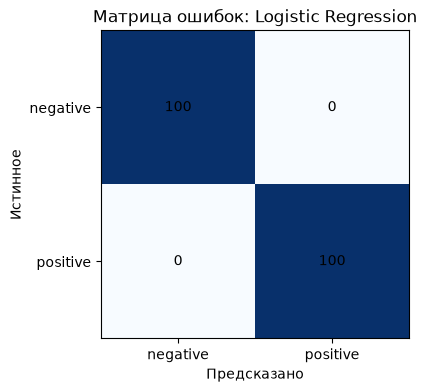

In [6]:
best_name = max(results, key=lambda k: results[k][2])
best_model, best_preds, best_acc = results[best_name]
print('Лучшая модель:', best_name, '| accuracy =', round(best_acc, 4))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['negative', 'positive'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['negative', 'positive'])
ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинное')
ax.set_title(f'Матрица ошибок: {best_name}')
plt.show()


In [7]:
# Проверка на новых, не встречавшихся отзывах
new_reviews = [
    "The pasta was incredibly tasty and the staff were super friendly.",
    "Worst experience ever, the burger was cold and the waiter was rude.",
    "Decent place, nothing special but the service was okay.",
    "Absolutely loved the cozy atmosphere and the amazing cocktails!",
    "The soup was bland and overpriced, very disappointing visit.",
]

new_clean = [clean_text(t) for t in new_reviews]
new_tfidf = vectorizer.transform(new_clean)
new_preds = best_model.predict(new_tfidf)

for text, pred in zip(new_reviews, new_preds):
    label = 'positive' if pred == 1 else 'negative'
    print(f'[{label:>8}] {text}')


[positive] The pasta was incredibly tasty and the staff were super friendly.
[negative] Worst experience ever, the burger was cold and the waiter was rude.
[negative] Decent place, nothing special but the service was okay.
[positive] Absolutely loved the cozy atmosphere and the amazing cocktails!
[negative] The soup was bland and overpriced, very disappointing visit.


## Вывод

TF-IDF признаки в сочетании с логистической регрессией / наивным Байесом
позволяют достаточно точно классифицировать тональность отзывов о
ресторанах и барах. Модель уверенно разделяет явно положительные и
отрицательные отзывы; ошибки чаще возникают на нейтральных/смешанных
формулировках ("decent place, nothing special..."), что характерно и для
реального датасета Yelp Polarity.

При наличии доступа в интернет этот же пайплайн без изменений применяется
к настоящему датасету `yelp_polarity` (см. код загрузки в начале ноутбука),
который содержит 560k+ реальных отзывов с разметкой тональности.
